In [17]:
!pip install pyspark matplotlib pandas

import os
import sys
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, sum, avg, count, desc, round as spark_round
import matplotlib.pyplot as plt
import pandas as pd

# 🔧 JAVA 21 FIX: Handle Security Manager issue
os.environ['PYSPARK_SUBMIT_ARGS'] = '--driver-java-options "-Djava.security.manager=allow" pyspark-shell'


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
# Initialize Spark Session
spark = SparkSession.builder \
    .appName("CODTECH_Task1_Notebook") \
    .config("spark.sql.shuffle.partitions", "200") \
    .config("spark.driver.extraJavaOptions", "-Djava.security.manager=allow") \
    .config("spark.executor.extraJavaOptions", "-Djava.security.manager=allow") \
    .getOrCreate()

print("✅ Spark Session Initialized")

✅ Spark Session Initialized


In [19]:
# Load Data
file_path = "data.csv"
df = spark.read.csv(file_path, header=True, inferSchema=True)

print(f"Total Raw Records: {df.count()}")
df.printSchema()
df.show(5)

Total Raw Records: 541909
root
 |-- InvoiceNo: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- InvoiceDate: string (nullable = true)
 |-- UnitPrice: double (nullable = true)
 |-- CustomerID: integer (nullable = true)
 |-- Country: string (nullable = true)

+---------+---------+--------------------+--------+--------------+---------+----------+--------------+
|InvoiceNo|StockCode|         Description|Quantity|   InvoiceDate|UnitPrice|CustomerID|       Country|
+---------+---------+--------------------+--------+--------------+---------+----------+--------------+
|   536365|   85123A|WHITE HANGING HEA...|       6|12/1/2010 8:26|     2.55|     17850|United Kingdom|
|   536365|    71053| WHITE METAL LANTERN|       6|12/1/2010 8:26|     3.39|     17850|United Kingdom|
|   536365|   84406B|CREAM CUPID HEART...|       8|12/1/2010 8:26|     2.75|     17850|United Kingdom|
|   536365|   8402

In [20]:
# Data Cleaning
# 1. Filter out null CustomerIDs
# 2. Filter out negative quantities (Returns/Cancellations)
df_clean = df.filter((col("CustomerID").isNotNull()) & (col("Quantity") > 0))

# Add TotalAmount column (Quantity * UnitPrice)
df_clean = df_clean.withColumn("TotalAmount", spark_round(col("Quantity") * col("UnitPrice"), 2))

df_clean.cache()
print(f"Cleaned Records: {df_clean.count()}")

Cleaned Records: 397924


+--------------+------------------+
|       Country|           Revenue|
+--------------+------------------+
|United Kingdom| 7308391.550000116|
|   Netherlands|285446.33999999997|
|          EIRE| 265545.9000000003|
|       Germany| 228867.1399999999|
|        France|209024.05000000005|
|     Australia|138521.30999999997|
|         Spain| 61577.10999999999|
|   Switzerland| 56443.94999999997|
|       Belgium|41196.340000000004|
|        Sweden|          38378.33|
+--------------+------------------+



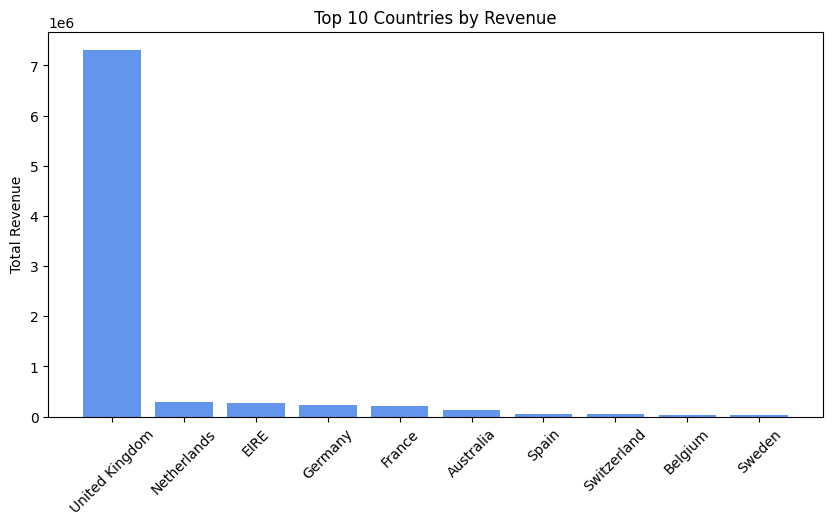

In [21]:
country_revenue = df_clean.groupBy("Country") \
    .agg(sum("TotalAmount").alias("Revenue")) \
    .orderBy(desc("Revenue")) \
    .limit(10)

country_revenue.show()

# Visualization
pdf_country = country_revenue.toPandas()
plt.figure(figsize=(10, 5))
plt.bar(pdf_country['Country'], pdf_country['Revenue'], color='cornflowerblue')
plt.title('Top 10 Countries by Revenue')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.show()

+----------------------------------+----------+
|Description                       |Total_Sold|
+----------------------------------+----------+
|PAPER CRAFT , LITTLE BIRDIE       |80995     |
|MEDIUM CERAMIC TOP STORAGE JAR    |77916     |
|WORLD WAR 2 GLIDERS ASSTD DESIGNS |54415     |
|JUMBO BAG RED RETROSPOT           |46181     |
|WHITE HANGING HEART T-LIGHT HOLDER|36725     |
|ASSORTED COLOUR BIRD ORNAMENT     |35362     |
|PACK OF 72 RETROSPOT CAKE CASES   |33693     |
|POPCORN HOLDER                    |30931     |
|RABBIT NIGHT LIGHT                |27202     |
|MINI PAINT SET VINTAGE            |26076     |
+----------------------------------+----------+



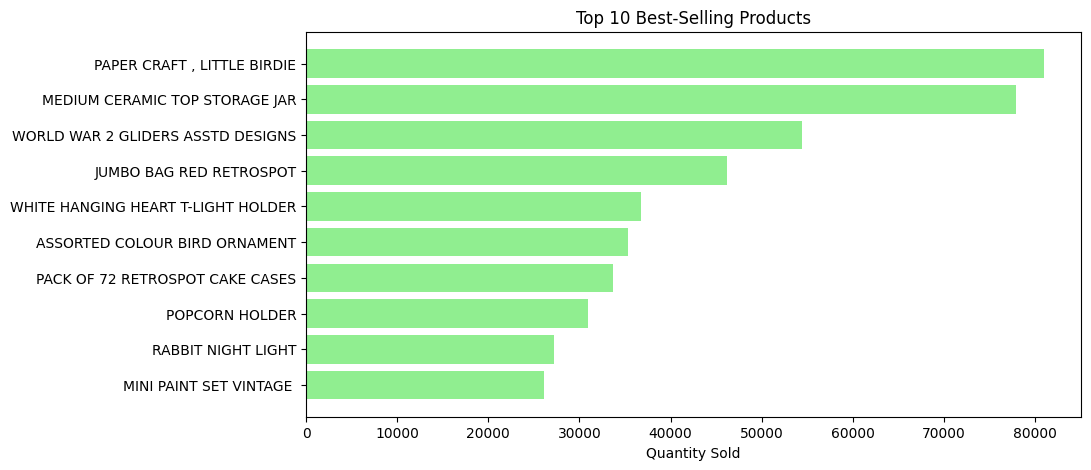

In [22]:
top_products = df_clean.groupBy("Description") \
    .agg(sum("Quantity").alias("Total_Sold")) \
    .orderBy(desc("Total_Sold")) \
    .limit(10)

top_products.show(truncate=False)

# Visualization
pdf_products = top_products.toPandas()
plt.figure(figsize=(10, 5))
plt.barh(pdf_products['Description'], pdf_products['Total_Sold'], color='lightgreen')
plt.xlabel('Quantity Sold')
plt.title('Top 10 Best-Selling Products')
plt.gca().invert_yaxis()
plt.show()

In [23]:
spark.stop()